In [1]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt # Needed to display the plots
from datetime import datetime, timedelta

In [2]:
"""
Get F1 Car Data
"""
url = "https://api.openf1.org/v1/car_data"

session_key = 9877
driver_number = 44
speed = '>= 0'

params = {
    'session_key':session_key,
    'driver_number':driver_number
}

headers = {}

response = requests.request("GET", url, headers=headers, params=params)

#create a json file with car data
car_data_json = response.json()
car_data_df = pd.DataFrame(car_data_json)

In [3]:
car_data_df

,date,session_key,drs,n_gear,speed,rpm,throttle,meeting_key,brake,driver_number
0,2025-10-26T19:08:49.034000+00:00,9877,0,0,0,0,0,1272,0,44
1,2025-10-26T19:08:49.474000+00:00,9877,0,0,0,0,0,1272,0,44
2,2025-10-26T19:08:49.714000+00:00,9877,0,0,0,0,0,1272,0,44
3,2025-10-26T19:08:49.874000+00:00,9877,0,0,0,0,0,1272,0,44
4,2025-10-26T19:08:50.594000+00:00,9877,0,0,0,0,0,1272,0,44
...,...,...,...,...,...,...,...,...,...,...
35550,2025-10-26T21:47:55.427000+00:00,9877,1,0,0,0,104,1272,104,44
35551,2025-10-26T21:47:55.587000+00:00,9877,1,0,0,0,104,1272,104,44
35552,2025-10-26T21:47:55.907000+00:00,9877,1,0,0,0,104,1272,104,44
35553,2025-10-26T21:47:56.067000+00:00,9877,1,0,0,0,104,1272,104,44


In [4]:
session_start_time = car_data_df['date'].min()
session_start_datetime = datetime.strptime(session_start_time, "%Y-%m-%dT%H:%M:%S.%f%z")
# session_start_time
session_end_time = car_data_df['date'].max()
session_end_datetime = datetime.strptime(session_end_time, "%Y-%m-%dT%H:%M:%S.%f%z")
time_elapsed = (session_end_datetime - session_start_datetime).total_seconds()
print(f'''
Session Start Time: {session_start_time}
Session End Time: {session_end_time}
Session Time Elapsed: {time_elapsed} seconds
''')


Session Start Time: 2025-10-26T19:08:49.034000+00:00
Session End Time: 2025-10-26T21:47:56.427000+00:00
Session Time Elapsed: 9547.393 seconds



In [123]:
car_data_df['session_time_elapsed_secs'] = (pd.to_datetime(car_data_df['date'], format='ISO8601') - session_start_datetime).dt.total_seconds()

<Axes: xlabel='session_time_elapsed_secs'>

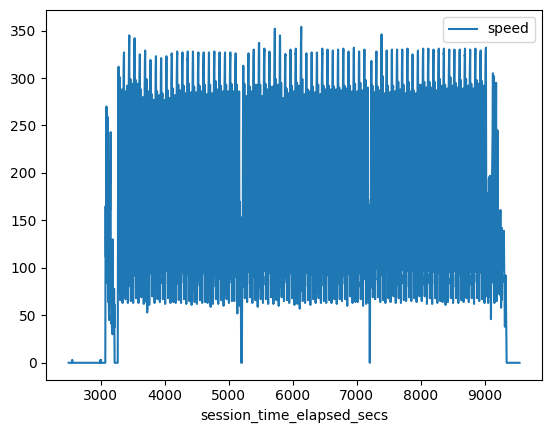

In [124]:
car_data_df_timebound = car_data_df.mask(car_data_df['session_time_elapsed_secs'] < 2500)
car_data_df_timebound.plot('session_time_elapsed_secs', 'speed')

In [5]:
# car_data_df_timebound.to_csv('2025_brazil_LH44_car_data.csv')
car_data_df_timebound

NameError: name 'car_data_df_timebound' is not defined

In [25]:
"""
Get F1 Driver Data
"""

url = "https://api.openf1.org/v1/drivers"

session_key = 9158

params = {
    'session_key':session_key
}
headers = {}

response = requests.request("GET", url, headers=headers, params=params)

driver_json = response.json()
# print(response.text)


In [18]:
enumerate(driver_json)

In [ ]:
for ii, record in enumerate(driver_json):
    print(ii)
    print(record)

In [6]:
"""
Get F1 Session Data
"""

url = "https://api.openf1.org/v1/sessions?country_name=Belgium&session_name=Sprint%20Qualifying&year=2023"

payload = {}
headers = {}

response = requests.request("GET", url, headers=headers, data=payload)

print(response.text)


[{"session_key":9286,"session_type":"Qualifying","session_name":"Sprint Qualifying","date_start":"2023-07-29T10:00:00+00:00","date_end":"2023-07-29T10:44:00+00:00","meeting_key":1216,"circuit_key":7,"circuit_short_name":"Spa-Francorchamps","country_key":16,"country_code":"BEL","country_name":"Belgium","location":"Spa-Francorchamps","gmt_offset":"02:00:00","year":2023}]


In [7]:
"""
Get F1 Car Location Data (On Track)
"""
url = "https://api.openf1.org/v1/location?"

session_key = 9877
driver_number = 44
# speed = '>= 0'

params = {
    'session_key':session_key,
    'driver_number':driver_number
}

headers = {}

response = requests.request("GET", url, headers=headers, params=params)

#create a json file with car data
car_location_json = response.json()
car_location_df = pd.DataFrame(car_location_json)

In [8]:
car_location_df

,date,session_key,meeting_key,driver_number,z,x,y
0,2025-10-26T19:08:05.738000+00:00,9877,1272,44,0,0,0
1,2025-10-26T19:08:06.038000+00:00,9877,1272,44,0,0,0
2,2025-10-26T19:08:06.218000+00:00,9877,1272,44,0,0,0
3,2025-10-26T19:08:06.398000+00:00,9877,1272,44,0,0,0
4,2025-10-26T19:08:06.638000+00:00,9877,1272,44,0,0,0
...,...,...,...,...,...,...,...
36335,2025-10-26T21:47:54.821000+00:00,9877,1272,44,22266,-807,1097
36336,2025-10-26T21:47:55.261000+00:00,9877,1272,44,22266,-807,1097
36337,2025-10-26T21:47:55.641000+00:00,9877,1272,44,22266,-807,1097
36338,2025-10-26T21:47:56.101000+00:00,9877,1272,44,22266,-807,1097


In [115]:
loc_session_start_time = car_location_df['date'].min()
loc_session_start_datetime = datetime.strptime(loc_session_start_time, "%Y-%m-%dT%H:%M:%S.%f%z")
car_location_df['session_time_elapsed_secs'] = (pd.to_datetime(car_location_df['date'], format='ISO8601') - loc_session_start_datetime).dt.total_seconds()

<Axes: xlabel='x'>

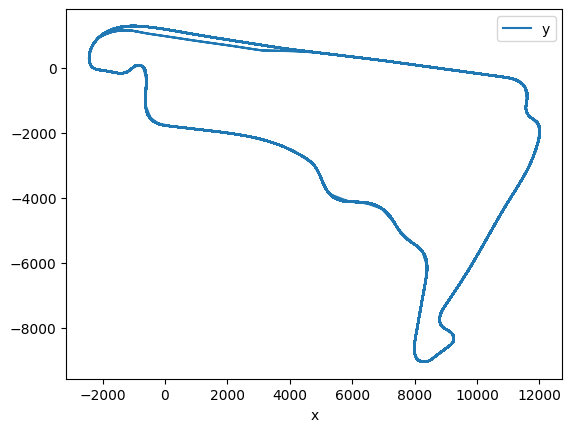

In [120]:
car_loc_df_timebound = car_location_df.mask(car_location_df['session_time_elapsed_secs'] < 2500)
car_loc_df_timebound.plot('x', 'y')